In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

## Fundamental matrix estimation

In this notebook we will estimate the fundamental matrix (F) from a set of matching points and we will qualitative compare the results of the custom implementation with those obtained with the opencv function findFundamentalMat().

For an introduction see https://docs.opencv.org/3.4/da/de9/tutorial_py_epipolar_geometry.html

(<Axes: >, <matplotlib.image.AxesImage at 0x711348476890>)

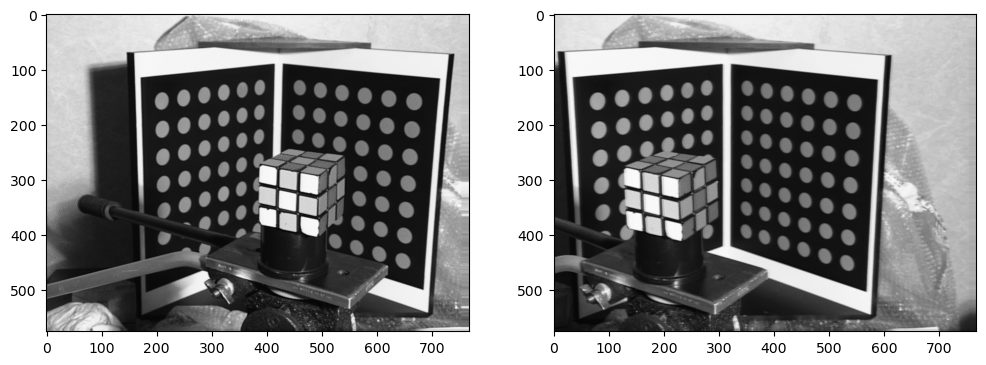

In [2]:
# Load and visualize image pair
# you may try other image pairs (already present in the images/ folder)
img1 = cv.imread('images/Rubik1.pgm', cv.IMREAD_GRAYSCALE)  
img2 = cv.imread('images/Rubik2.pgm', cv.IMREAD_GRAYSCALE)  
plt.figure(figsize=(12,6))
plt.subplot(121),plt.imshow(img1,cmap="gray") 
plt.subplot(122),plt.imshow(img2,cmap="gray")

The first step for the Fundamental matrix estimation is the detection of matches. 

We will use SIFT to identify points candidates, then we will find matches (as done in lab2)

In [3]:
sift = cv.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

pts1 = []
pts2 = []

bf = cv.BFMatcher()
matches = bf.knnMatch(des1,des2, k=2)
        
for i,(m,n) in enumerate(matches):
    if m.distance < 0.8*n.distance:
        pts2.append(kp2[m.trainIdx].pt)
        pts1.append(kp1[m.queryIdx].pt)
        
pts1 = np.int32(pts1)
pts2 = np.int32(pts2)

Here we will implement our custom_eight_points() function.

In [ ]:
def custom_eight_points(pts1, pts2):
    #Here the code for the custom function. The first step is the definition of the matrix A (Af=0)
    #containing our knowns and obtained from the matches pts1 and pts2.
    #Then, we will implement the singular value decomposition of A and we will return the unknown f
    

In [4]:
#utils function to draw the epipolar lines
def drawlines(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r,c = img1.shape
    img1 = cv.cvtColor(img1,cv.COLOR_GRAY2BGR)
    img2 = cv.cvtColor(img2,cv.COLOR_GRAY2BGR)
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        img1 = cv.line(img1, (x0,y0), (x1,y1), color,1)
        img1 = cv.circle(img1,tuple(pt1),5,color,-1)
        img2 = cv.circle(img2,tuple(pt2),5,color,-1)
    return img1,img2

In [ ]:
# estimate the fundamental matrix and check its dimension
F_custom = custom_eight_points(pts1,pts2)
print(np.shape(F_custom))

Find epilines corresponding to points in right image (second image) and drawing its lines on left image.

In [ ]:
lines1 = cv.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2,F_custom)
lines1 = lines1.reshape(-1,3)
img5,img6 = drawlines(img1,img2,lines1,pts1,pts2)

Find epilines corresponding to points in left image (first image) and drawing its lines on right image.

In [ ]:
lines2 = cv.computeCorrespondEpilines(pts1.reshape(-1,1,2), 1,F_custom)
lines2 = lines2.reshape(-1,3)
img3,img4 = drawlines(img2,img1,lines2,pts2,pts1)
plt.figure(figsize=(12,6))
plt.subplot(121),plt.imshow(img5)
plt.subplot(122),plt.imshow(img3)
plt.show()

### If you try to pick your own points?

In [ ]:
#Pick 8 points and try to perform the same steps

### Here we compare our implementation with the results of the opencv function findFundamentalMat()

To see how the function works see: https://amroamroamro.github.io/mexopencv/matlab/cv.findFundamentalMat.html

and https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#ga59b0d57f46f8677fb5904294a23d404a

In [5]:
# estimate the fundamental matrix
F, mask = cv.findFundamentalMat(pts1,pts2,cv.FM_LMEDS) #try to change method and see the differences FM_8POINT or FM_RANSAC

To make the estimation less noisy, we remove the outliers from the matches. UNCOMMENT only after the first run to see how the epipolar lines change

In [6]:
## We select only inlier points
#pts1 = pts1[mask.ravel()==1]
#pts2 = pts2[mask.ravel()==1]

We compute here the position of the epipoles that are the points that verify the equation

*e* F = 0

In [7]:
from scipy.linalg import null_space

el = null_space(F)
print(el)
er = null_space(F.T)
print(er)

[[-9.99814063e-01]
 [ 1.92829685e-02]
 [-7.45694416e-05]]
[[ 9.99899107e-01]
 [-1.42046311e-02]
 [ 7.22804268e-05]]


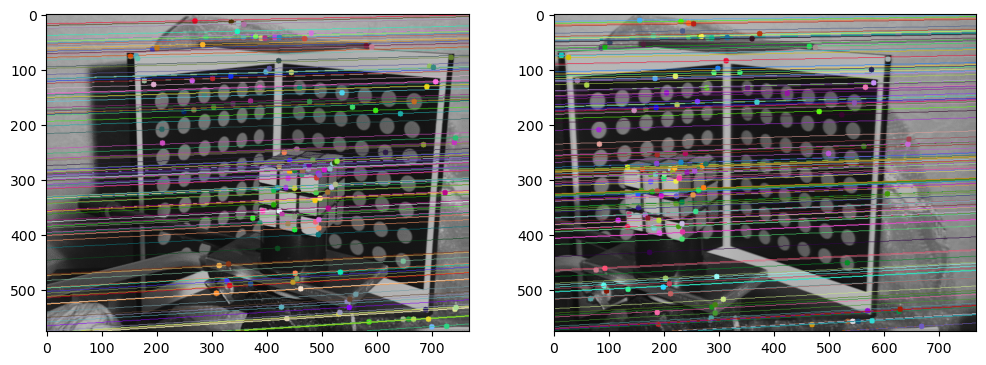

In [8]:
# Find epilines corresponding to points in right image (second image) and
# drawing its lines on left image
lines1 = cv.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2,F)
lines1 = lines1.reshape(-1,3)
img5,img6 = drawlines(img1,img2,lines1,pts1,pts2)
# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image
lines2 = cv.computeCorrespondEpilines(pts1.reshape(-1,1,2), 1,F)
lines2 = lines2.reshape(-1,3)
img3,img4 = drawlines(img2,img1,lines2,pts2,pts1)
plt.figure(figsize=(12,6))
plt.subplot(121),plt.imshow(img5)
plt.subplot(122),plt.imshow(img3)
plt.show()